# WhatsApp Chat Analyzer

This notebook reads a WhatsApp chat export file and provides comprehensive statistics, interactive charts, word frequency analysis, and emoji insights.

### **Notebook Organization:**
1.  **Setup:** Package installation, library imports, and font configuration.
2.  **Data Parsing:** Converts raw `.txt` exports into a structured Pandas DataFrame with cleaned timestamps.
3.  **Basic Chat Statistics:** Summary of total members, messages, words, media, links, and VCF files.
4.  **User Activity Analysis:** Identifying most/least active participants and conversation starters/enders.
5.  **Timeline Analysis:** Visualizing daily and monthly message trends.
6.  **Heatmaps:** Activity patterns mapped by day of week, month, and date.
7.  **Message Text Analysis:** Cleaning, tokenizing, and filtering text for keyword extraction.
8.  **Word Clouds:** Generating visual word summaries for both English and Bengali scripts.
9.  **Message Length Analysis:** Analyzing verbosity across different users.
10. **Emoji Analysis:** Extracting and visualizing the most used emojis.
11. **Hourly Activity:** Breakdown of chat engagement by time of day.

### **Design Note:**
Every analysis function in this notebook is designed to **build and return** data (DataFrames) or visualizations (Plotly figures) rather than calling `print()` or `.show()` internally. This modular approach ensures that the logic can be seamlessly integrated into other platforms, such as a **Streamlit** dashboard, by simply wrapping the returns in `st.plotly_chart()` or `st.dataframe()`.

## 1. Setup

### 1.1 Install required packages

In [1]:
!pip -q install urlextract
!pip -q install pygments
!pip -q install emoji
!pip -q install wordcloud

### 1.2 Import libraries
All imports are kept in one place, so it is easy to see what this notebook depends on.

In [2]:
import re
import os
import random
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from urlextract import URLExtract
from pygments.lexers import guess_lexer
from pygments.util import ClassNotFound
from wordcloud import WordCloud
import emoji

### 1.3 Download Bengali font
This font is only needed later, for drawing the Bengali word cloud. We download it once here so the file is ready when we need it.

In [3]:
!wget -q https://raw.githubusercontent.com/hmoazzem/bangla-fonts/refs/heads/master/Siyamrupali.ttf -O Siyamrupali.ttf

BENGALI_FONT_PATH = 'Siyamrupali.ttf'


### 1.4 File paths and Default Contrast
Change these two paths to match your own Google Drive / Colab file locations.

In [4]:
# Dataset directory path
DATASET_PATH = '/kaggle/input/datasets/codebysumit/synthetic-college-whatsapp-group-chat-dataset'

# Path to the raw WhatsApp chat export (.txt file)
CHAT_FILE_PATH = os.path.join(DATASET_PATH, "whatsapp_chats/WhatsApp Chat with ABC Poly Cyber Forensics 2022-26.txt")

# Path to your Bengali/Banglish stopwords list (one word per line)
STOPWORDS_FILE_PATHS = [
    os.path.join(DATASET_PATH, "stopwords/stopwords_bengali.txt"),
    os.path.join(DATASET_PATH, "stopwords/stopwords_banglish.txt"),
    os.path.join(DATASET_PATH, "stopwords/stopwords_english.txt"),
]

In [5]:
random.seed(42)

## 2. Data Parsing
WhatsApp exports the chat as plain text. Each line normally looks like:

`8/20/24, 10:15 AM - Sumit: Hello everyone`

The functions below turn lines like this into a clean pandas DataFrame.

### 2.1 Line pattern and date/time helpers

In [6]:
# Regex that matches one WhatsApp chat line: date, time, sender (optional), message
CHAT_LINE_PATTERN = re.compile(
    r'^(\d{1,2}/\d{1,2}/\d{2,4}),\s*'      # date
    r'(\d{1,2}:\d{2}(?:\s?[APap][Mm])?)'   # time
    r'\s*-\s*'                              # separator
    r'(?:([^:\n]+?):\s)?'                   # sender (optional, System messages have none)
    r'(.*)$'                                # message text
)

# Order to try when guessing which number is Day / Month / Year.
# WhatsApp usually exports as Month/Day/Year (e.g. 8/20/24), so we try that first.
DATE_FORMAT_PRIORITY = [
    ('M', 'D', 'Y'),
    ('D', 'M', 'Y'),
    ('Y', 'M', 'D'),
]


def normalize_date(date_str):
    """
    Turn a raw date string (like '8/20/24') into a clean 'DD-MM-YYYY' string.
    Returns None if the date cannot be understood.
    """
    if not date_str:
        return None
    date_str = str(date_str).strip()
    parts = re.split(r'[/.-]', date_str)
    if len(parts) != 3:
        return None
    try:
        nums = [int(p) for p in parts]
    except ValueError:
        return None

    for order in DATE_FORMAT_PRIORITY:
        role_map = dict(zip(order, nums))
        day, month, year = role_map['D'], role_map['M'], role_map['Y']
        if year < 100:
            year += 2000 if year < 70 else 1900
        if not (1 <= month <= 12) or not (1 <= day <= 31):
            continue
        try:
            parsed_date = datetime(year, month, day)
            return parsed_date.strftime('%d-%m-%Y')
        except ValueError:
            continue
    return None


def normalize_time(time_str):
    """
    Turn a raw time string (like '10:15 AM') into 24 hour format 'HH:MM'.
    If it cannot be understood, the original string is returned unchanged.
    """
    time_str = time_str.strip()
    for fmt in ('%I:%M %p', '%I:%M%p', '%H:%M'):
        try:
            return datetime.strptime(time_str, fmt).strftime('%H:%M')
        except ValueError:
            continue
    return time_str


### 2.2 Parse the chat export file

In [7]:
def parse_whatsapp_chat(file_path):
    """
    Read a WhatsApp .txt export and turn it into a list of message dictionaries.
    Multi-line messages (like a message with a line break) are joined back together.
    Lines with no sender (System messages, like 'X added Y') get sender = 'System'.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.read().split('\n')

    messages = []
    current = None
    for line in lines:
        match = CHAT_LINE_PATTERN.match(line)
        if match:
            if current:
                current['message'] = current['message'].strip()
                messages.append(current)
            date, time_str, sender, text = match.groups()
            current = {
                'date_raw': date,
                'date_ddmmyyyy': normalize_date(date),
                'time_raw': time_str,
                'time_24hr': normalize_time(time_str),
                'sender': sender if sender else 'System',
                'message': text,
            }
        else:
            # This line is a continuation of the previous message (no date/time prefix)
            if current:
                current['message'] += '\n' + line

    if current:
        current['message'] = current['message'].strip()
        messages.append(current)

    return messages


def build_chat_dataframe(file_path):
    """
    Full pipeline: parse the chat file and return a ready-to-use DataFrame
    with clean date/time columns and helper columns (day, month, year, hour...).
    """
    messages = parse_whatsapp_chat(file_path)
    df = pd.DataFrame(messages)

    df = df.rename(columns={
        'date_ddmmyyyy': 'date_formatted',
        'time_24hr': 'time_formatted',
    })

    df['date_formatted'] = pd.to_datetime(df['date_formatted'], format='%d-%m-%Y', errors='coerce')
    df['time_formatted'] = pd.to_datetime(df['time_formatted'], format='%H:%M', errors='coerce').dt.time

    df['day'] = df['date_formatted'].dt.day
    df['month'] = df['date_formatted'].dt.month_name()
    df['year'] = df['date_formatted'].dt.year
    df['day_name'] = df['date_formatted'].dt.day_name()

    df['hours'] = df['time_formatted'].apply(lambda t: t.hour if pd.notnull(t) else np.nan)
    df['minutes'] = df['time_formatted'].apply(lambda t: t.minute if pd.notnull(t) else np.nan)

    return df.reset_index(drop=True)


### 2.3 Load the data
`messages_df` is the main DataFrame used everywhere in this notebook.

In [8]:
messages_df = build_chat_dataframe(CHAT_FILE_PATH)
print(f"Data loaded. Total rows: {len(messages_df)}")
messages_df.head()

Data loaded. Total rows: 172


,date_raw,date_formatted,time_raw,time_formatted,sender,message,day,month,year,day_name,hours,minutes
0,8/15/22,2022-08-15,10:00 AM,10:00:00,System,Messages and calls are end-to-end encrypted. O...,15,August,2022,Monday,10,0
1,8/15/22,2022-08-15,10:05 AM,10:05:00,System,"Pritam Saha created group ""ABC Poly Cyber Fore...",15,August,2022,Monday,10,5
2,8/15/22,2022-08-15,10:10 AM,10:10:00,System,Pritam Saha added +91 98300 12345,15,August,2022,Monday,10,10
3,8/15/22,2022-08-15,10:12 AM,10:12:00,System,"Pritam Saha added Debasish Roy, Ananya Dutta, ...",15,August,2022,Monday,10,12
4,8/15/22,2022-08-15,10:15 AM,10:15:00,System,Pritam Saha changed this group's description,15,August,2022,Monday,10,15


### 2.4 DataFram into Whatsapp txt

In [9]:
def dataframe_to_whatsapp_txt(df, output_file_path):
    """
    Reverses the build_chat_dataframe process by converting a DataFrame
    back into the standard WhatsApp .txt export format.
    """
    with open(output_file_path, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            # Use raw columns if they exist to preserve original format,
            # otherwise fallback to formatted ones.
            date = row.get('date_raw', row['date_formatted'].strftime('%m/%d/%y'))
            time = row.get('time_raw', row['time_formatted'].strftime('%I:%M %p'))
            sender = row['sender']
            message = str(row['message'])

            if sender == 'System':
                # System messages don't have a 'Sender: ' prefix
                line = f"{date}, {time} - {message}\n"
            else:
                line = f"{date}, {time} - {sender}: {message}\n"

            f.write(line)
    print(f"Successfully saved DataFrame to {output_file_path}")

In [10]:
if 2+2 == 22:
  # Example usage:
  dataframe_to_whatsapp_txt(messages_df, 'reconstructed_chat.txt')

In [11]:
# Let's preview the first few lines of what the export would look like
def preview_export(df, limit=5):
    for _, row in df.head(limit).iterrows():
        date = row.get('date_raw', row['date_formatted'].strftime('%m/%d/%y'))
        time = row.get('time_raw', row['time_formatted'])
        sender = row['sender']
        msg = row['message']
        if sender == 'System':
            print(f"{date}, {time} - {msg}")
        else:
            print(f"{date}, {time} - {sender}: {msg}")

In [12]:
if 2+2 == 22:
  print("Preview of reconstructed text format:")
  preview_export(messages_df)

### 2.5 Assigned the Facke Name to All Member

In [13]:
def fake_number():
    # Clearly fictional Indian-style mobile number, random each time
    first = random.choice([70,71,72,73,74,76,77,81,82,83,86,87,89,90,91,92,93,94,95,96,97,98,99])
    rest = random.randint(10000000, 99999999)
    s = f"{first}{rest}"
    return f"+91 {s[:5]} {s[5:]}"

In [14]:
def fake_name(size=100):
  first_names = [
      "Arka","Debjit","Sourav","Priyanka","Ritam","Ankita","Subhojit","Moumita",
      "Sujoy","Riya","Kaustav","Ishita","Rohan","Sneha","Abir","Poulomi",
      "Tanmoy","Debolina","Sagnik","Payel","Anirban","Shreya","Bappa","Sohini",
      "Rudra","Titas","Suman","Barsha","Avishek","Nandini","Pritam","Ushoshi",
      "Souptik","Mahua","Indranil","Rimjhim","Biswajit","Aparajita","Rajarshi","Tiyasha",
      "Sourabh","Debasmita","Arindam","Swagata","Koushik","Trina","Sourish","Ankona",
      "Amitava","Susmita","Debanjan","Piyali","Rittik","Ipsita","Sudip","Manisha",
      "Angshuman","Ruponti","Pratik","Debarati", # Existing names
      "Alok", "Disha", "Gaurav", "Heena", "Kiran", "Lalita", "Manoj", "Nisha",
      "Omkar", "Pooja", "Rajesh", "Sapna", "Tarun", "Uma", "Vikas", "Jyoti",
      "Rahul", "Swati", "Deepak", "Meena", "Sagar", "Anjali", "Kartik", "Shilpa",
      "Vivek", "Preeti", "Sanjay", "Renu", "Bharat", "Divya", "Kapil", "Neha",
      "Arjun", "Kavita", "Pankaj", "Ritika", "Ganesh", "Sonia", "Harish", "Asha",
      "Vijay", "Suman", "Nikhil", "Priya", "Ashok", "Madhu", "Sunil", "Rekha",
      "Ajay", "Shweta", "Amit", "Seema", "Ravi", "Geeta", "Mohan", "Sarita",
      "Prem", "Nirmala", "Suresh", "Lata", "Anil", "Megha", "Prakash", "Sujata",
      "Vinod", "Smita", "Girish", "Kajal", "Dinesh", "Monica", "Ashish", "Rina",
      "Rajiv", "Tina", "Siddharth", "Pallavi", "Akash", "Sheetal", "Rohit", "Kamini",
      "Sandeep", "Mamta", "Sumit", "Poonam", "Vikram", "Shobha", "Yash", "Rashmi",
      "Jatin", "Arti", "Bhavin", "Anju", "Chetan", "Mita", "Deepesh", "Ritu",
      "Kunal", "Vandana", "Amitabh", "Jaya", "Shahrukh", "Kajol", "Salman", "Madhuri",
      "Aamir", "Juhi", "Akshay", "Raveena", "Hrithik", "Kareena", "Ranbir", "Deepika",
      "Shahid", "Priyanka", "Varun", "Alia", "Sidharth", "Shraddha", "Ranveer", "Anushka",
      "Ayushmann", "Taapsee", "Rajkummar", "Bhumi", "Vicky", "Sara", "Aditya", "Tara",
      "Ishaan", "Janhvi", "Kartik", "Ananya", "Tiger", "Disha", "Sushant", "Kriti"
  ]
  surnames = [
      "Chatterjee","Banerjee","Mukherjee","Ghosh","Das","Roy","Sarkar","Dutta",
      "Bhattacharya","Chakraborty","Mondal","Halder","Pal","Saha","Bose","Sen",
      "Adhikari","Karmakar","Naskar","Biswas","Mandal","Samanta","Majumder","Dey",
      "Sengupta","Chowdhury", # Existing surnames
      "Agarwal", "Sharma", "Singh", "Yadav", "Kumar", "Gupta", "Mehta", "Patel",
      "Shah", "Jain", "Verma", "Rao", "Reddy", "Naidu", "Chauhan", "Khan",
      "Ansari", "Malik", "Pandey", "Mishra", "Tripathi", "Dubey", "Thakur", "Rathore",
      "Goyal", "Modi", "Gandhi", "Nehru", "Azad", "Bhagat", "Patil", "Desai",
      "Kulkarni", "Joshi", "Shinde", "More", "Gaikwad", "Sonawane", "Pawar", "Kale",
      "Raut", "Sutar", "Jadhav", "Bhosale", "Sathe", "Dalvi", "Kadam", "Dhawan",
      "Kohli", "Dhoni", "Tendulkar", "Gavaskar", "Kapil", "Yuvraj", "Rohit", "Virat",
      "Anil", "Rahul", "Dravid", "Sachin", "Ganguly", "Sourav", "Laxman", "Virender"
  ]

  random.shuffle(first_names)
  random.shuffle(surnames)

  all_possible_unique_names = set()
  # Generate all unique combinations and store them in a set for uniqueness.
  for fn_val in first_names:
      for sn_val in surnames:
          all_possible_unique_names.add(f"{fn_val} {sn_val}")

  # Convert to list and shuffle to randomize the selection
  shuffled_unique_names = list(all_possible_unique_names)
  random.shuffle(shuffled_unique_names)

  if size > len(shuffled_unique_names):
      print(f"Warning: Requested {size} unique fake names, but only {len(shuffled_unique_names)} are possible. Returning all {len(shuffled_unique_names)} unique names.")
      return shuffled_unique_names
  else:
      return shuffled_unique_names[:size]

In [15]:
def assign_fake_name(df, name_ratio=0.5):
    """
    Assign a fake name or fake mobile number to all members and entities.

    Parameters:
    - df: The chat DataFrame.
    - name_ratio: Float (0 to 1). The proportion of entities that will get a fake name.
                  The remainder (1 - name_ratio) will get a fake mobile number.
    """
    import re
    import random

    def match_case(target, reference):
        if reference.isupper(): return target.upper()
        if reference.islower(): return target.lower()
        if len(reference) > 0 and reference[0].isupper() and (len(reference) == 1 or reference[1:].islower()):
            return target.capitalize()
        return target

    # 1. Identify unique entities (senders and mentioned entities)
    real_senders = set(str(s) for s in df['sender'].unique() if s and s != 'System')
    phone_pattern = r'\+?\d[\d\s\-]{7,14}\d'
    all_text = " ".join(df['message'].astype(str))
    prefixed_names = set(re.findall(r'[~@]\s*([^\s+].+?)(?=\s+added|\s+joined|\s+left|\s+created|\s+changed|\s+removed|$)', all_text))
    found_numbers = set(re.findall(phone_pattern, all_text))

    all_real_entities = list(real_senders.union(found_numbers).union(prefixed_names))
    if not all_real_entities:
        return df.copy()

    random.shuffle(all_real_entities)

    # 2. Split entities into 'Name' group and 'Number' group
    num_total = len(all_real_entities)
    num_names = int(num_total * name_ratio)

    entities_for_names = all_real_entities[:num_names]
    entities_for_numbers = all_real_entities[num_names:]

    # 3. Generate identities
    names_pool = fake_name(len(entities_for_names))
    mapping = dict(zip(entities_for_names, names_pool))

    for entity in entities_for_numbers:
        mapping[entity] = fake_number()

    redacted_df = df.copy()
    redacted_df['sender'] = redacted_df['sender'].apply(lambda s: mapping.get(s, s))

    # 4. Redaction Logic
    entities_sorted = sorted(all_real_entities, key=len, reverse=True)
    pattern_str = r'(~\s*|@)?(' + '|'.join(re.escape(e) for e in entities_sorted) + r')'
    regex = re.compile(pattern_str, re.IGNORECASE)
    lookup = {k.lower(): k for k in all_real_entities}

    def redact(text):
        if not isinstance(text, str): return text
        text = text.replace('\u202f', ' ').replace('\u00a0', ' ')

        def replace(match):
            prefix = match.group(1) or ""
            matched_val = match.group(2)
            orig_key = lookup.get(matched_val.lower())

            if orig_key in mapping:
                replacement = match_case(mapping[orig_key], matched_val)
                return f"{prefix}{replacement}"
            return match.group(0)

        return regex.sub(replace, text)

    redacted_df['message'] = redacted_df['message'].apply(redact)
    return redacted_df

In [16]:
if 2+2 == 22:
  # Final verification run
  redacted_messages_df = assign_fake_name(messages_df)
  dataframe_to_whatsapp_txt(redacted_messages_df, '/content/WhatsApp Chat with Polytechnic Support Group 2022-2026.txt')

  print("Final Preview of Redacted Chat:")
  preview_export(redacted_messages_df, limit=10)

## 3. Basic Chat Statistics

### 3.1 Total members

In [17]:
def get_total_members(df):
    """
    Return (count, list_of_names) of all members who sent at least one message.
    Excludes 'System' messages (case-insensitive).
    """
    # Use case-insensitive check for System and handle potential None values
    members = df[~df['sender'].fillna('').str.contains('^system$', case=False, na=False)]['sender'].unique()
    # Filter out any lingering None or empty strings
    members = [m for m in members if m and str(m).strip()]
    return len(members), members

In [18]:
member_count, member_list = get_total_members(messages_df)
print(f"Total number of members: {member_count}")
print("\nMember list:")
for i, member in enumerate(member_list, 1):
    print(f"    {i} - {member}")

    if i == 20:
        break

Total number of members: 57

Member list:
    1 - Pritam Saha
    2 - Debasish Roy
    3 - Ananya Dutta
    4 - Subhajit Das
    5 - Riya Sen
    6 - Sourav Kundu
    7 - Sneha Sarkar
    8 - Abhishek Banerjee
    9 - Poulami Ghosh
    10 - Niladri Shekhar
    11 - Sayantan Bose
    12 - Tanmay Mukherjee
    13 - Ritam Bhattacharya
    14 - Sudipta Chakraborty
    15 - Amitava Pal
    16 - Dipanjan Maiti
    17 - Arpita Samanta
    18 - Monalisa Seal
    19 - Sandip Pramanik
    20 - Joydeep Paul


### 3.2 Chat date range (start and end)

In [19]:
def get_chat_date_range(df, person='all'):
    """
    Return (start_date, end_date, start_time, end_time) for the chat,
    or for one person if 'person' is given.
    """
    if person == 'all':
        df = df[df['sender'] != 'System']
    else:
        df = df[df['sender'] == person]

    start_date = df['date_formatted'].min().strftime('%d-%m-%Y')
    end_date = df['date_formatted'].max().strftime('%d-%m-%Y')
    start_time = df['time_formatted'].min().strftime('%H:%M')
    end_time = df['time_formatted'].max().strftime('%H:%M')

    return start_date, end_date, start_time, end_time


In [20]:
start_date, end_date, start_time, end_time = get_chat_date_range(messages_df)
print(f"Chat started on: {start_date} at {start_time}")
print(f"Chat ended on:   {end_date} at {end_time}")

Chat started on: 15-08-2022 at 09:00
Chat ended on:   20-05-2027 at 21:15


### 3.3 Total messages, words, media, links, and VCF files

In [21]:
def get_total_message_count(df, person='all'):
    """Total number of messages sent (excluding System messages)."""
    if person == 'all':
        df = df[df['sender'] != 'System']
    else:
        df = df[df['sender'] == person]
    return df.shape[0]


def get_total_word_count(df, person='all'):
    """Total number of words across all messages."""
    if person != 'all':
        df = df[df['sender'] == person]
    return df['message'].apply(lambda msg: len(msg.split())).sum()


def get_total_media_count(df, person='all'):
    """Total number of media messages (photo, video, sticker etc)."""
    if person != 'all':
        df = df[df['sender'] == person]
    return df['message'].apply(lambda msg: "<Media omitted>" in msg).sum()


def get_total_link_count(df, person='all'):
    """
    Find every link shared in the chat.
    Returns (total_count, links_dataframe).
    """
    extractor = URLExtract()
    links_data = []

    if person != 'all':
        df_filtered = df[df['sender'] == person].copy()
    else:
        df_filtered = df[df['sender'] != 'System'].copy()

    for _, row in df_filtered.iterrows():
        for url in extractor.find_urls(row['message']):
            links_data.append({
                'date': row['date_formatted'],
                'time': row['time_formatted'],
                'sender_name': row['sender'],
                'link': url,
            })

    links_df = pd.DataFrame(links_data)
    return len(links_data), links_df


def get_total_vcf_count(df, person='all'):
    """
    Find every contact card (.vcf file) shared in the chat.
    Returns (total_count, vcf_dataframe).
    """
    if person != 'all':
        df_filtered = df[df['sender'] == person].copy()
    else:
        df_filtered = df[df['sender'] != 'System'].copy()

    vcf_mask = df_filtered['message'].str.contains(r'\.vcf fileattachedfile attached', case=False, na=False)
    vcf_df = df_filtered[vcf_mask].copy()

    return vcf_df.shape[0], vcf_df


In [22]:
print(f"Total number of messages: {get_total_message_count(messages_df)}")
print(f"Total number of words: {get_total_word_count(messages_df)}")
print(f"Total number of media messages: {get_total_media_count(messages_df)}")

total_links, links_df = get_total_link_count(messages_df)
print(f"Total number of links: {total_links}")
display(links_df.head(2))

total_vcf, vcf_df = get_total_vcf_count(messages_df)
print(f"Total VCF files shared: {total_vcf}")
if total_vcf > 0:
    display(vcf_df[['date_formatted', 'sender', 'message']].head(2))

Total number of messages: 161
Total number of words: 1681
Total number of media messages: 0
Total number of links: 10


,date,time,sender_name,link
0,2022-08-15,11:10:00,Riya Sen,https://wbsctesd-exam.in/notices/cyber-forensi...
1,2022-10-12,13:25:00,Arpita Samanta,https://drive.google.com/drive/folders/fake-fo...


Total VCF files shared: 0


## 4. User Activity Analysis

### 4.1 Most active members (bar chart + pie chart)

In [23]:
def plot_most_active_members(df, top_n='all'):
    """
    Build a horizontal bar chart and a pie chart of the members who sent the
    most messages.
    Returns (user_counts_df, fig_bar, fig_pie).
    """
    df_filtered = df[df['sender'] != 'System']

    user_counts = df_filtered['sender'].value_counts().reset_index()
    user_counts.columns = ['User', 'Message Count']

    if top_n != 'all' and isinstance(top_n, int):
        user_counts = user_counts.head(top_n)

    plot_df = user_counts.sort_values(by='Message Count', ascending=True)
    label = top_n if top_n != 'all' else ''

    fig_bar = px.bar(
        plot_df,
        x='Message Count',
        y='User',
        orientation='h',
        title=f'Top {label} Active Users (Message Count)',
        color='Message Count',
        color_continuous_scale='Viridis',
        text_auto=True,
    )
    fig_bar.update_layout(
        yaxis_title='User Name',
        xaxis_title='Number of Messages',
        yaxis={'type': 'category'},
        margin=dict(l=200),
        height=max(400, len(user_counts) * 25),
        template='plotly_white',
    )

    fig_pie = px.pie(
        user_counts,
        values='Message Count',
        names='User',
        title=f'Message Distribution among Top {label} Users',
        hole=0.3,
    )
    fig_pie.update_traces(textposition='inside', textinfo='percent+label')

    return user_counts[['User', 'Message Count']], fig_bar, fig_pie

In [24]:
top_users_df, fig_bar, fig_pie = plot_most_active_members(messages_df, top_n=10)

In [25]:
fig_bar.show()

In [26]:
fig_pie.show(renderer="iframe")

### 4.2 Least active members

In [27]:
def plot_least_active_members(df, bottom_n=10):
    """
    Build a bar chart and a pie chart of the least active members
    (sorted from least to most active).
    Returns (least_active_df, fig_bar, fig_pie).
    """
    df_filtered = df[df['sender'] != 'System']

    user_counts = df_filtered['sender'].value_counts().reset_index()
    user_counts.columns = ['User', 'Message Count']

    least_active_df = user_counts.sort_values(by='Message Count', ascending=True).head(bottom_n)

    fig_bar = px.bar(
        least_active_df,
        x='Message Count',
        y='User',
        orientation='h',
        title=f'Bottom {bottom_n} Least Active Users',
        color='Message Count',
        color_continuous_scale='Magma',
        text_auto=True,
    )
    fig_bar.update_layout(
        yaxis_title='User Name',
        xaxis_title='Number of Messages',
        yaxis={'type': 'category', 'categoryorder': 'total ascending'},
        margin=dict(l=200),
        template='plotly_white',
    )

    fig_pie = px.pie(
        least_active_df,
        values='Message Count',
        names='User',
        title=f'Message Distribution among Bottom {bottom_n} Users',
        hole=0.3,
    )
    fig_pie.update_traces(textposition='inside', textinfo='percent+label')

    return least_active_df, fig_bar, fig_pie


In [28]:
least_active_df, fig_bar, fig_pie = plot_least_active_members(messages_df, bottom_n=10)

In [29]:
fig_bar.show(renderer="iframe")

In [30]:
fig_pie.show(renderer="iframe")

### 4.3 Who starts and ends the chat each day

In [31]:
def get_chat_starters_and_enders(df):
    """
    Find who sends the first and the last message on each date.
    Returns (starter_counts_df, ender_counts_df, fig_starters, fig_enders).
    """
    df_clean = df[df['sender'] != 'System'].copy()
    df_sorted = df_clean.sort_values(['date_formatted', 'time_formatted'])

    starters = df_sorted.groupby('date_formatted').first().reset_index()
    starter_counts = starters['sender'].value_counts().reset_index()
    starter_counts.columns = ['User', 'Count']

    enders = df_sorted.groupby('date_formatted').last().reset_index()
    ender_counts = enders['sender'].value_counts().reset_index()
    ender_counts.columns = ['User', 'Count']

    fig_starters = px.pie(
        starter_counts.head(10),
        values='Count',
        names='User',
        title='Top 10 Daily Conversation Starters (First Message of Day)',
        hole=0.4,
    )
    fig_starters.update_traces(textinfo='percent+label')

    fig_enders = px.pie(
        ender_counts.head(10),
        values='Count',
        names='User',
        title='Top 10 Daily Conversation Enders (Last Message of Day)',
        hole=0.4,
    )
    fig_enders.update_traces(textinfo='percent+label')

    return starter_counts, ender_counts, fig_starters, fig_enders


In [32]:
starters_df, enders_df, fig_starters, fig_enders = get_chat_starters_and_enders(messages_df)

In [33]:
fig_starters.show(renderer="iframe")

In [34]:
fig_enders.show(renderer="iframe")

### 4.4 Sunburst chart: Year > Month > Weekday > Member

In [35]:
def plot_message_sunburst(df):
    """
    Full sunburst chart showing every member at the outer ring.
    Best used when the group has a small number of members.
    """
    df_clean = df[df['sender'] != 'System'].copy()

    sunburst_df = (
        df_clean.groupby(['year', 'month', 'day_name', 'sender'])
        .size()
        .reset_index(name='message_count')
    )

    fig = px.sunburst(
        sunburst_df,
        path=['year', 'month', 'day_name', 'sender'],
        values='message_count',
        title='Hierarchy of Messages: Year > Month > Weekday > Member',
        color='message_count',
        color_continuous_scale='RdBu',
        height=800,
    )
    fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
    return fig


def plot_message_sunburst_grouped(df, top_n_members=15):
    """
    Same idea as plot_message_sunburst, but groups smaller members into
    'Others' so the chart stays readable in large groups.
    """
    group_cols = ['year', 'month', 'day_name', 'sender']
    df_clean = df[df['sender'] != 'System'].copy()
    df_clean = df_clean.dropna(subset=group_cols)

    grouped = df_clean.groupby(group_cols).size().reset_index(name='message_count')

    def group_smaller_members(group):
        year_val, month_val, day_val = group.name

        if len(group) > top_n_members:
            top_members = group.nlargest(top_n_members, 'message_count')
            others_count = group.iloc[top_n_members:]['message_count'].sum()
            others_row = pd.DataFrame({
                'year': [year_val],
                'month': [month_val],
                'day_name': [day_val],
                'sender': ['Others'],
                'message_count': [others_count],
            })
            return pd.concat([top_members, others_row])

        group = group.copy()
        group['year'] = year_val
        group['month'] = month_val
        group['day_name'] = day_val
        return group

    sunburst_df = grouped.groupby(
        ['year', 'month', 'day_name'], group_keys=False
    ).apply(group_smaller_members, include_groups=False)

    for col in group_cols:
        sunburst_df[col] = sunburst_df[col].astype(str)
    sunburst_df = sunburst_df[~(sunburst_df[group_cols] == 'nan').any(axis=1)]

    fig = px.sunburst(
        sunburst_df,
        path=['year', 'month', 'day_name', 'sender'],
        values='message_count',
        title=f'Message Hierarchy (Top {top_n_members} Members shown individually)',
        color='message_count',
        color_continuous_scale='RdBu',
        height=800,
    )
    fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
    return fig


In [36]:
# Full sunburst (good for small groups)
fig = plot_message_sunburst(messages_df)
fig.show(renderer="iframe")

In [37]:
if 2+2 == 22:
    # Grouped sunburst (good for large groups, keeps chart readable)
    fig = plot_message_sunburst_grouped(messages_df, top_n_members=15)
    fig.show(renderer="iframe")

## 5. Timeline Analysis (Daily and Monthly Trend)

### 5.1 Build the timeline data

In [38]:
def get_message_timeline(df, person='all'):
    """
    Build daily and monthly message-count timelines.
    Returns (timeline_daily_df, timeline_monthly_df).
    """
    if person != 'all':
        df = df[df['sender'] == person].copy()
    else:
        df = df.copy()

    df = df[df['sender'] != 'System'].copy()

    # Daily timeline
    timeline_daily = (
        df.groupby('date_formatted').count()['message']
        .reset_index()
        .sort_values('date_formatted')
    )
    timeline_daily['time'] = (
        timeline_daily['date_formatted'].dt.day.astype(str) + '-' +
        timeline_daily['date_formatted'].dt.month.astype(str) + '-' +
        timeline_daily['date_formatted'].dt.year.astype(str)
    )

    # Monthly timeline
    df['month_num'] = df['date_formatted'].dt.month
    timeline_monthly = (
        df.groupby(['year', 'month_num', 'month']).count()['message']
        .reset_index()
        .sort_values(['year', 'month_num'])
    )
    timeline_monthly['time'] = timeline_monthly['month'] + '-' + timeline_monthly['year'].astype(str)

    return timeline_daily, timeline_monthly


### 5.2 Daily and monthly line charts

In [39]:
def plot_daily_message_timeline(timeline_daily):
    """Line chart of message count per day."""
    fig = px.line(
        timeline_daily,
        x='time',
        y='message',
        title='Daily Message Frequency Timeline',
        labels={'time': 'Date', 'message': 'Number of Messages'},
        markers=True,
        template='plotly_white',
    )
    fig.update_layout(xaxis_tickangle=-45, height=500, hovermode='x unified')
    return fig


def plot_monthly_message_timeline(timeline_monthly):
    """Line chart of message count per month."""
    fig = px.line(
        timeline_monthly,
        x='time',
        y='message',
        title='Monthly Message Frequency Timeline',
        labels={'time': 'Month-Year', 'message': 'Number of Messages'},
        markers=True,
        template='plotly_white',
    )
    fig.update_layout(xaxis_tickangle=-45, height=500, hovermode='x unified')
    return fig

In [40]:
timeline_daily, timeline_monthly = get_message_timeline(messages_df, person='all')

In [41]:
plot_daily_message_timeline(timeline_daily).show(renderer="iframe")

In [42]:
plot_monthly_message_timeline(timeline_monthly).show(renderer="iframe")

### 5.3 Most active day of week and month

In [43]:
def plot_most_active_day_and_month(df, person='all'):
    """
    Bar chart of message count by day of week, and by month.
    Returns (fig_day, fig_month).
    """
    if person != 'all':
        df = df[df['sender'] == person].copy()
    else:
        df = df.copy()

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    busy_day = df['day_name'].value_counts().reset_index()
    busy_day.columns = ['day_name', 'message_count']

    fig_day = px.bar(
        busy_day,
        x='day_name',
        y='message_count',
        title=f'Most Active Days: {person}',
        category_orders={'day_name': day_order},
        color='message_count',
        color_continuous_scale='Viridis',
        text_auto=True,
    )
    fig_day.update_layout(xaxis_title='Day of Week', yaxis_title='Messages', template='plotly_white')

    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
    busy_month = df['month'].value_counts().reset_index()
    busy_month.columns = ['month', 'message_count']

    fig_month = px.bar(
        busy_month,
        x='month',
        y='message_count',
        title=f'Most Active Months: {person}',
        category_orders={'month': month_order},
        color='message_count',
        color_continuous_scale='Plasma',
        text_auto=True,
    )
    fig_month.update_layout(xaxis_title='Month', yaxis_title='Messages', template='plotly_white')

    return fig_day, fig_month


In [44]:
fig_day, fig_month = plot_most_active_day_and_month(messages_df, person='all')


In [45]:
fig_day.show(renderer="iframe")

In [46]:
fig_month.show(renderer="iframe")

## 6. Heatmaps

### 6.1 GitHub-style daily activity heatmap

In [47]:
def plot_daily_activity_heatmap(df, person='all', start_date=None, end_date=None):
    """
    GitHub-style heatmap: one cell per day, arranged by week (x) and
    day of week (y). Returns a Plotly figure, or None if no data matches.
    """
    if person != 'all':
        df = df[df['sender'] == person].copy()
    else:
        df = df.copy()

    if start_date:
        df = df[df['date_formatted'] >= pd.to_datetime(start_date)]
    if end_date:
        df = df[df['date_formatted'] <= pd.to_datetime(end_date)]

    if df.empty:
        print('No data found for the selected range/person.')
        return None

    daily_activity = df.groupby('date_formatted').size().reset_index(name='message_count')
    daily_activity['week'] = daily_activity['date_formatted'].dt.isocalendar().week
    daily_activity['year'] = daily_activity['date_formatted'].dt.year
    daily_activity['day_name'] = daily_activity['date_formatted'].dt.day_name()
    daily_activity['date_str'] = daily_activity['date_formatted'].dt.strftime('%d-%m-%Y')
    daily_activity['week_label'] = (
        daily_activity['year'].astype(str) + '-W' + daily_activity['week'].astype(str).str.zfill(2)
    )

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    custom_greens = [
        [0, 'rgb(240, 240, 240)'],
        [0.05, 'rgb(198, 228, 139)'],
        [0.5, 'rgb(35, 154, 59)'],
        [1.0, 'rgb(25, 97, 39)'],
    ]

    fig = px.density_heatmap(
        daily_activity,
        x='week_label',
        y='day_name',
        z='message_count',
        category_orders={'day_name': day_order},
        color_continuous_scale=custom_greens,
        title=f'Daily Message Activity Heatmap: {person}',
        hover_data={'week_label': True, 'day_name': True, 'message_count': True, 'date_str': True},
        labels={'week_label': 'Week', 'day_name': 'Day', 'message_count': 'Messages', 'date_str': 'Date'},
        text_auto=True,
    )
    fig.update_layout(
        xaxis_title='Weeks (Chronological)',
        yaxis_title='',
        template='plotly_white',
        height=450,
        paper_bgcolor='white',
        plot_bgcolor='white',
    )
    fig.update_traces(xgap=3, ygap=3)
    return fig


In [48]:
fig = plot_daily_activity_heatmap(messages_df, person='all')

In [49]:
if fig:
    fig.show(renderer="iframe")

### 6.2 Weekday vs Month heatmap

In [50]:
def plot_weekday_month_heatmap(df, person='all'):
    """
    Heatmap of message count by (month, day of week).
    Returns a Plotly figure, or None if no data matches.
    """
    if person != 'all':
        df = df[df['sender'] == person].copy()
    else:
        df = df.copy()

    if df.empty:
        print('No data found for the selected person.')
        return None

    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    activity_matrix = df.groupby(['month', 'day_name']).size().reset_index(name='message_count')

    custom_greens = [
        [0, 'rgb(240, 240, 240)'],
        [0.05, 'rgb(198, 228, 139)'],
        [0.5, 'rgb(35, 154, 59)'],
        [1.0, 'rgb(25, 97, 39)'],
    ]

    fig = px.density_heatmap(
        activity_matrix,
        x='month',
        y='day_name',
        z='message_count',
        category_orders={'month': month_order, 'day_name': day_order},
        color_continuous_scale=custom_greens,
        title=f'Weekday vs Month Activity: {person}',
        labels={'month': 'Month', 'day_name': 'Day of Week', 'message_count': 'Messages'},
        text_auto=True,
    )
    fig.update_layout(
        xaxis_title='Month',
        yaxis_title='',
        template='plotly_white',
        height=500,
        paper_bgcolor='white',
        plot_bgcolor='white',
    )
    fig.update_traces(xgap=3, ygap=3)
    return fig


In [51]:
fig = plot_weekday_month_heatmap(messages_df, person='all')

In [52]:
if fig:
    fig.show(renderer="iframe")

### 6.3 Day-of-month vs Month heatmap

In [53]:
def plot_day_of_month_heatmap(df, person='all'):
    """
    Heatmap of message count for every day-of-month (1-31) against every month.
    Returns a Plotly figure, or None if no data matches.
    """
    if person != 'all':
        df = df[df['sender'] == person].copy()
    else:
        df = df.copy()

    if df.empty:
        print('No data found for the selected person.')
        return None

    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']

    matrix = df.groupby(['month', 'day']).size().unstack(fill_value=0)
    matrix = matrix.reindex(index=month_order, columns=range(1, 32), fill_value=0)

    custom_greens = [
        [0, 'rgb(240, 240, 240)'],
        [0.01, 'rgb(198, 228, 139)'],
        [0.1, 'rgb(123, 201, 111)'],
        [0.4, 'rgb(35, 154, 59)'],
        [1.0, 'rgb(25, 97, 39)'],
    ]

    fig = px.imshow(
        matrix,
        labels=dict(x='Day of Month', y='Month', color='Messages'),
        x=list(range(1, 32)),
        y=month_order,
        color_continuous_scale=custom_greens,
        title=f'Activity Matrix: Day of Month vs Month ({person})',
        text_auto=True,
        aspect='auto',
    )
    fig.update_layout(
        xaxis=dict(tickmode='linear', tick0=1, dtick=1),
        yaxis_title='',
        template='plotly_white',
        height=700,
        margin=dict(l=100, r=20, t=50, b=50),
        paper_bgcolor='white',
        plot_bgcolor='white',
    )
    fig.update_traces(xgap=2, ygap=2)
    return fig


In [54]:
fig = plot_day_of_month_heatmap(messages_df, person='all')

In [55]:
if fig:
    fig.show(renderer="iframe")

## 7. Message Text Analysis (Cleaning and Tokenizing)
This section removes emojis, links, media tags, and code blocks from messages, then breaks the remaining text into clean words. This is needed before we can count the most-used words or draw a word cloud.

### 7.1 Detect and remove code blocks
People sometimes paste code snippets in the chat. We do not want code counted as normal words, so we detect and drop those blocks.

In [56]:
# Programming languages we treat as "code", not natural language text
CODE_LANGUAGES = {
    'C', 'C++', 'Java', 'Python', 'JavaScript', 'TypeScript',
    'PHP', 'Ruby', 'Go', 'Rust', 'Swift', 'Kotlin', 'Scala',
    'SQL', 'HTML', 'CSS', 'Bash', 'Shell', 'PowerShell',
    'R', 'MATLAB', 'Perl', 'Lua', 'Haskell', 'Dart',
    'Assembly', 'Makefile', 'Dockerfile', 'YAML', 'JSON', 'XML',
}


def is_code_block(text, min_lines=2):
    """Return True if pygments thinks this block of text is programming code."""
    lines = [line for line in text.strip().splitlines() if line.strip()]
    if len(lines) < min_lines:
        return False

    try:
        lexer = guess_lexer(text)
        lexer_name = lexer.name

        if 'text' in lexer_name.lower():
            return False

        for lang in CODE_LANGUAGES:
            if lang.lower() in lexer_name.lower():
                return True

    except ClassNotFound:
        return False

    return False


def remove_code_from_message(text):
    """Split a message into blocks, drop code blocks, keep normal text."""
    blocks = re.split(r'\n{2,}', text.strip())
    clean_blocks = [block.strip() for block in blocks if not is_code_block(block)]
    return ' '.join(clean_blocks).strip()

### 7.2 Keep only real text messages
This drops System messages, media placeholders, deleted messages, emojis, and code, leaving only the plain text people actually typed.

In [57]:
def get_text_only_messages(df):
    """Return a copy of df with only real, human-typed text messages left."""
    df = df[df['sender'] != 'System']
    df = df[df['message'] != '<Media omitted>']
    df = df[df['message'] != 'This message was deleted']
    df = df[df['message'] != 'You deleted this message']
    df = df.copy()

    df['message'] = df['message'].apply(lambda x: x.replace(' <This message was edited>', ''))

    emoji_pattern = re.compile(
        '['
        '\U0001F600-\U0001F64F'   # emoticons
        '\U0001F300-\U0001F5FF'   # symbols & pictographs
        '\U0001F680-\U0001F6FF'   # transport & map
        '\U0001F1E0-\U0001F1FF'   # flags
        '\u2702-\u27B0'           # dingbats
        '\u24C2-\U0001F251'       # enclosed characters
        '\U0001F900-\U0001F9FF'   # supplemental symbols
        '\U0001FA00-\U0001FA6F'   # chess symbols etc.
        '\U0001FA70-\U0001FAFF'   # additional symbols
        '\u2500-\u2BEF'           # box drawings, misc technical
        '\u3000-\u303F'           # CJK symbols
        '\u3200-\u32FF'           # enclosed CJK
        '\uFE30-\uFE4F'           # CJK compatibility forms
        '\u2600-\u26FF'           # misc symbols (sun, cloud etc)
        '\u2068\u2069'            # WhatsApp control characters
        ']+',
        flags=re.UNICODE,
    )
    df['message'] = df['message'].apply(lambda x: emoji_pattern.sub(' ', x))
    df['message'] = df['message'].apply(remove_code_from_message)

    df = df[df['message'].str.strip() != '']
    return df.reset_index(drop=True)


### 7.3 Clean and tokenize individual words
`clean_word` cleans up a single word (removing links, phone numbers, file names, punctuation etc). `tokenize_message` uses it to turn a full message into a clean list of words.

In [58]:
def clean_word(word):
    """
    Clean one word by removing links, emails, phone numbers, file names,
    punctuation, and other WhatsApp-specific noise.
    Returns the cleaned word, or an empty string if the word should be dropped.
    """
    # 0. Drop URLs and emails
    if re.search(r'https?://|ftp://', word, re.IGNORECASE):
        return ''
    if re.match(r'^[\w\.\+\-]+@[\w\-]+\.[\w\.]+$', word, re.IGNORECASE):
        return ''
    if re.search(r'\.(com|in|org|net|io|gov|co|me|app|online|edu|uk|us|info|biz)\b', word, re.IGNORECASE):
        return ''
    if re.search(
        r'(forms\.gle|drive\.google|docs\.google|meet\.google'
        r'|youtube\.com|youtu\.be|bit\.ly|tinyurl)',
        word, re.IGNORECASE,
    ):
        return ''

    # 1. Remove zero-width / invisible unicode characters
    invisible_chars = [
        '\u200e', '\u200d', '\u200c', '\u200f',
        '\u200b', '\u00ad', '\ufeff', '\u200a',
        '\u2060', '\u2062', '\u2063', '\u2064',
    ]
    for ch in invisible_chars:
        word = word.replace(ch, '')

    # 2. Strip emojis and pictographic symbols
    emoji_pattern = re.compile(
        '['
        '\U0001F600-\U0001F64F'
        '\U0001F300-\U0001F5FF'
        '\U0001F680-\U0001F6FF'
        '\U0001F1E0-\U0001F1FF'
        '\U00002702-\U000027B0'
        '\U000024C2-\U0001F251'
        '\U0001F900-\U0001F9FF'
        '\U0001FA00-\U0001FA6F'
        '\U0001FA70-\U0001FAFF'
        '\U00002500-\U00002BEF'
        '\U00003000-\U0000303F'
        '\U00003200-\U000032FF'
        '\U0000FE30-\U0000FE4F'
        ']+',
        flags=re.UNICODE,
    )
    word = emoji_pattern.sub('', word)

    # 3. Remove WhatsApp mention prefixes (@~Name -> Name)
    word = re.sub(r'^[@~]+', '', word)

    # 4. Remove phone numbers
    if re.match(r'^\+?\d[\d\s\-]{7,}$', word):
        return ''

    # 5. Remove file/media references
    if re.search(r'\.(vcf|pdf|jpg|jpeg|png|mp4|mp3|zip|exe|apk|docx?|xlsx?|pptx?|csv|txt)$', word, re.IGNORECASE):
        return ''

    # 6. Remove poll artifacts
    poll_patterns = [
        r'^\(?\d+\s*votes?\)?$',
        r'^option:?$',
        r'^poll:?$',
        r'^\(\d+$',
        r'^\d+\)$',
    ]
    for pattern in poll_patterns:
        if re.match(pattern, word, re.IGNORECASE):
            return ''

    # 7. Remove date/time stamps
    if re.match(r'^\d{1,2}[:/\-]\d{1,2}([:/\-]\d{2,4})?$', word):
        return ''

    # 8. Remove standalone numbers and number+symbol combos
    if re.match(r'^[₹Rs\.]*\d[\d,./\-₹]*[/\-]?$', word):
        return ''

    # 9. Remove long numeric sequences (roll numbers etc)
    if re.match(r'^[A-Z]{1,5}\d{4,}$', word) or re.match(r'^\d{6,}$', word):
        return ''

    # 10. Clean embedded special characters
    word = re.sub(r'[@~|\\]', '', word)

    # 11. Strip leading/trailing punctuation clusters
    strip_chars = r"""[.?!,;:<>(){}\[\]\-\*_/\\|@~#%^&+=`'"…•·।]"""
    word = re.sub(r'^' + strip_chars + r'+', '', word)
    word = re.sub(strip_chars + r'+$', '', word)

    # 12. Remove symbols-only tokens
    if re.match(r'^[^a-zA-Z\u0900-\u09FF\u0980-\u09FF]+$', word):
        return ''

    # 13. Remove noise: single-character tokens (except a few valid English words)
    if len(word) == 1 and word not in ('a', 'A', 'I', 'i'):
        if not re.match(r'[\u0900-\u09FF]', word):
            return ''

    # 14. Normalize repeated punctuation (e.g. '...', '!!!')
    word = re.sub(r'[.?!]{2,}', ' ', word).strip()

    # 15. Remove leftover WhatsApp metadata words
    meta_tokens = {
        'omitted', 'attached', 'file', 'sticker', 'image', 'video',
        'audio', 'gif', 'document', 'deleted', 'missed', 'call',
        'null', 'undefined',
    }
    if word.lower() in meta_tokens:
        return ''

    return word.strip()


def tokenize_message(message):
    """Turn one message string into a list of clean, lowercase words."""
    if not isinstance(message, str) or not message.strip():
        return []

    message = re.sub(r'https?://\S+|ftp://\S+', ' ', message, flags=re.IGNORECASE)
    message = re.sub(r'[\w\.\+\-]+@[\w\-]+\.[\w\.]+', ' ', message, flags=re.IGNORECASE)

    text = message.lower()
    text = re.sub(r'[.?!,;:<>(){}\[\]/\\|@~#\n\t\r]', ' ', text)
    text = text.replace('_', ' ').replace('*', ' ')
    for ch in ['\u2018', '\u2019', '\u201c', '\u201d', '\u2013', '\u2014', '\u2015', '\u00b7']:
        text = text.replace(ch, ' ')

    cleaned_words = []
    for raw_token in text.split():
        cleaned = clean_word(raw_token)
        for sub_word in cleaned.split():
            if sub_word.strip():
                cleaned_words.append(sub_word.strip())

    return cleaned_words


### 7.4 Count the most-used words

In [59]:
def get_top_words(df, stop_words_file_path, person='all'):
    """
    Return a DataFrame of (word, count), sorted from most to least frequent,
    with stopwords removed.
    Supports single file path (str/os.PathLike) or a list of paths.
    """
    if person != 'all':
        df = df[df['sender'] == person]

    df = get_text_only_messages(df)

    all_words = []
    for message in df['message']:
        all_words.extend(tokenize_message(message))

    # Handle both single path and list of paths
    if isinstance(stop_words_file_path, (str, os.PathLike)):
        paths = [stop_words_file_path]
    else:
        paths = stop_words_file_path

    stopwords = set()
    for path in paths:
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                stopwords.update(f.read().splitlines())

    filtered_words = [word for word in all_words if word not in stopwords]

    word_counts_df = pd.DataFrame(Counter(filtered_words).most_common(), columns=['word', 'count'])
    return word_counts_df.sort_values(by='count', ascending=False).reset_index(drop=True)

## 8. Word Cloud

### 8.1 Build the word cloud images

In [60]:
def make_word_cloud(df, stop_words_file_path, person='all', bengali_font_path=BENGALI_FONT_PATH,
                     width=800, height=800, max_words=200):
    """
    Build separate word clouds for Bengali script and English/Banglish script.
    Supports single file path (str/os.PathLike) or a list of paths for stopwords.
    """
    # get_top_words already handles the path/list logic
    word_df = get_top_words(df, stop_words_file_path, person=person)
    if word_df.empty or word_df['count'].sum() == 0:
        return None, {}, None, {}

    bengali_mask = word_df['word'].str.contains(r'[\u0980-\u09FF]', regex=True, na=False)
    df_bengali = word_df[bengali_mask].copy()
    df_english = word_df[~bengali_mask].copy()

    freq_bengali = dict(zip(df_bengali['word'], df_bengali['count'])) if not df_bengali.empty else {}
    freq_english = dict(zip(df_english['word'], df_english['count'])) if not df_english.empty else {}

    common_kwargs = dict(
        background_color='white',
        width=width,
        height=height,
        min_font_size=10,
        max_words=max_words,
        colormap='tab10',
    )

    img_bengali = None
    if freq_bengali:
        try:
            wc_bengali = WordCloud(**common_kwargs, font_path=bengali_font_path)
            wc_bengali.generate_from_frequencies(freq_bengali)
            img_bengali = wc_bengali.to_array()
        except Exception:
            img_bengali = None

    img_english = None
    if freq_english:
        try:
            wc_english = WordCloud(**common_kwargs)
            wc_english.generate_from_frequencies(freq_english)
            img_english = wc_english.to_array()
        except Exception:
            img_english = None

    return img_bengali, freq_bengali, img_english, freq_english

### 8.2 Show the word clouds

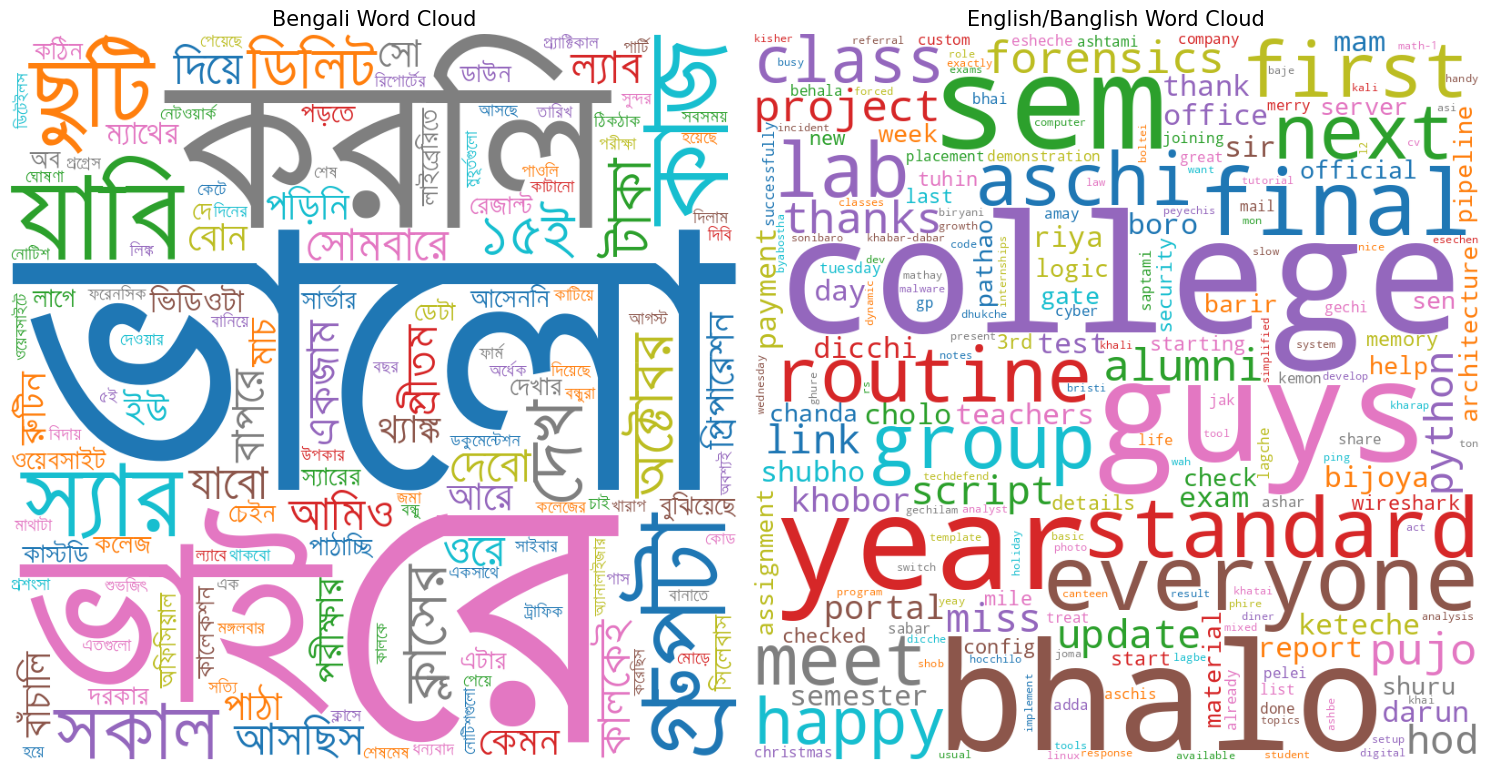

In [61]:
img_bengali, freq_bengali, img_english, freq_english = make_word_cloud(
    messages_df,
    STOPWORDS_FILE_PATHS,
    person='all',
    bengali_font_path=BENGALI_FONT_PATH,
)

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

if img_bengali is not None:
    ax[0].imshow(img_bengali)
    ax[0].set_title('Bengali Word Cloud', fontsize=15)
    ax[0].axis('off')

if img_english is not None:
    ax[1].imshow(img_english)
    ax[1].set_title('English/Banglish Word Cloud', fontsize=15)
    ax[1].axis('off')

plt.tight_layout()
plt.show()

### 8.3 Top word frequency bar charts
One reusable function, called twice: once for Bengali words and once for English words.

In [62]:
def plot_word_frequency_bar(word_freq, title, top_n=20):
    """
    Horizontal bar chart of the top N words from a {word: count} dictionary.
    Returns a Plotly figure, or None if word_freq is empty.
    """
    if not word_freq:
        return None

    top_items = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)[:top_n]
    words, counts = zip(*top_items)
    plot_df = pd.DataFrame({'Word': words, 'Frequency': counts})

    fig = px.bar(
        plot_df,
        x='Frequency',
        y='Word',
        orientation='h',
        title=title,
        color='Frequency',
        color_continuous_scale='Viridis',
        text='Frequency',
    )
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        template='plotly_white',
        height=600,
    )
    return fig


In [63]:
fig_bengali = plot_word_frequency_bar(freq_bengali, 'Top 20 Bengali Words Frequency', top_n=20)

In [64]:
if fig_bengali:
    fig_bengali.show(renderer="iframe")
else:
    print('No Bengali words found to plot.')


In [65]:
fig_english = plot_word_frequency_bar(freq_english, 'Top 20 English Words Frequency', top_n=20)
if fig_english:
    fig_english.show(renderer="iframe")
else:
    print('No English words found to plot.')

In [66]:
fig_english = plot_word_frequency_bar(freq_english, 'Top 20 English Words Frequency', top_n=20)
if fig_english:
    fig_english.show(renderer="iframe")
else:
    print('No English words found to plot.')

### 8.4 Top words for one specific person

In [67]:
def plot_top_words_for_person(df, stop_words_path, person='all', top_n=20):
    """
    Bar chart of the most frequent words used by one person (or everyone).
    Supports single file path (str/os.PathLike) or a list of paths for stopwords.
    """
    word_freq_df = get_top_words(df, stop_words_path, person=person)
    if word_freq_df.empty:
        print(f'No words found for person: {person}')
        return None

    top_words_df = word_freq_df.head(top_n)

    fig = px.bar(
        top_words_df,
        x='count',
        y='word',
        orientation='h',
        title=f'Top {top_n} Most Frequent Words - {person}',
        labels={'count': 'Frequency Count', 'word': 'Words'},
        color='count',
        color_continuous_scale='Viridis',
        text_auto=True,
    )
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        template='plotly_white',
        height=max(400, top_n * 25),
    )
    return fig

In [68]:
# Change 'person' below to any member name from the member list printed in Section 3.1
fig = plot_top_words_for_person(messages_df, STOPWORDS_FILE_PATHS, person='all', top_n=10)

In [69]:
if fig:
    fig.show(renderer="iframe")

## 9. Message Length Analysis

In [70]:
def plot_message_length_distribution(df, top_n=10):
    """
    Box plot of message length (word count) for the top N most active senders.
    Returns a Plotly figure.
    """
    df_filtered = df[df['sender'] != 'System'].copy()
    df_filtered['word_count'] = df_filtered['message'].apply(lambda x: len(str(x).split()))

    top_senders = df_filtered['sender'].value_counts().head(top_n).index.tolist()
    df_plot = df_filtered[df_filtered['sender'].isin(top_senders)]

    fig = px.box(
        df_plot,
        x='sender',
        y='word_count',
        color='sender',
        title=f'Message Length Distribution for Top {top_n} Senders',
        labels={'sender': 'User', 'word_count': 'Word Count per Message'},
        points='outliers',
        template='plotly_white',
    )
    fig.update_layout(
        xaxis_title='Sender',
        yaxis_title='Number of Words',
        showlegend=False,
        height=600,
    )
    return fig


In [71]:
plot_message_length_distribution(messages_df, top_n=10).show(renderer="iframe")


## 10. Emoji Analysis

### 10.1 Emoji frequency table

In [72]:
def get_emoji_stats(df, person='all'):
    """
    Count every emoji used in the chat.
    Returns a DataFrame with columns: emoji, count, percentage.
    """
    if person != 'all':
        df = df[df['sender'] == person]

    all_emojis = []
    for message in df['message']:
        if pd.isna(message):
            continue
        all_emojis.extend([item['emoji'] for item in emoji.emoji_list(message)])

    if not all_emojis:
        return pd.DataFrame(columns=['emoji', 'count', 'percentage'])

    emoji_counts = Counter(all_emojis)
    total_count = sum(emoji_counts.values())

    emoji_df = pd.DataFrame(emoji_counts.items(), columns=['emoji', 'count'])
    emoji_df['percentage'] = (emoji_df['count'] / total_count) * 100
    return emoji_df.sort_values(by='count', ascending=False).reset_index(drop=True)


In [73]:
emoji_df = get_emoji_stats(messages_df, person='all')
emoji_df.head(10)

,emoji,count,percentage


### 10.2 Top emojis pie chart

In [74]:
def plot_top_emojis_pie(emoji_df, top_n=10):
    """Pie chart of the top N most used emojis."""
    top_emojis = emoji_df.head(top_n).copy()

    fig = px.pie(
        top_emojis,
        values='count',
        names='emoji',
        title=f'Top {top_n} Emojis by Percentage Share',
        hole=0.3,
        template='plotly_white',
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(height=600)
    return fig


In [75]:
plot_top_emojis_pie(emoji_df, top_n=10).show(renderer="iframe")


## 11. Hourly and Time-of-Day Activity

### 11.1 Hourly stacked bar chart

In [76]:
def plot_hourly_activity(df, person='all'):
    """
    Stacked bar chart of message count per hour of day (0-23),
    with each sender shown as a separate color segment.
    Returns a Plotly figure, or None if there is no data.
    """
    df_clean = df[df['sender'] != 'System'].copy()
    if person != 'all':
        df_clean = df_clean[df_clean['sender'] == person]

    if df_clean.empty:
        print(f'No data found for: {person}')
        return None

    df_clean['hours'] = df_clean['hours'].astype(int)
    hourly_data = df_clean.groupby(['hours', 'sender']).size().reset_index(name='message_count')

    fig = px.bar(
        hourly_data,
        x='hours',
        y='message_count',
        color='sender',
        title=f'Hourly Message Distribution: {person}',
        labels={'hours': 'Hour of Day (24hr format)', 'message_count': 'Number of Messages', 'sender': 'Member'},
        template='plotly_white',
        text_auto=True,
    )
    fig.update_layout(
        xaxis=dict(tickmode='linear', tick0=0, dtick=1),
        barmode='stack',
        height=600,
        hovermode='x unified',
    )
    return fig


In [77]:
fig = plot_hourly_activity(messages_df, person='all')


In [78]:
if fig:
    fig.show(renderer="iframe")

### 11.2 Weekly schedule heatmap (day vs time-of-day period)

In [79]:
def get_day_period(hour):
    """Map an hour (0-23) to a named period of the day."""
    if 4 <= hour < 8:
        return 'Early Morning'
    elif 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Late Night'


def plot_weekly_schedule_heatmap(df, person='all'):
    """
    Modern-styled heatmap of activity: day of week (x) vs period of day (y).
    Returns a Plotly figure, or None if there is no data.
    """
    df_clean = df[df['sender'] != 'System'].copy()
    if person != 'all':
        df_clean = df_clean[df_clean['sender'] == person]

    if df_clean.empty:
        print(f'No data for {person}')
        return None

    df_clean['period'] = df_clean['hours'].apply(get_day_period)

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    period_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night']

    grid_df = df_clean.groupby(['day_name', 'period']).size().reset_index(name='count')
    pivot = grid_df.pivot(index='period', columns='day_name', values='count').fillna(0)
    pivot = pivot.reindex(index=period_order, columns=day_order)

    custom_colors = [
        [0.0, '#3d3d3d'],   # Inactive
        [0.3, '#734d26'],   # Low
        [1.0, '#ff8c00'],   # Peak
    ]

    fig = px.imshow(
        pivot,
        labels=dict(x='Day of Week', y='Time of Day', color='Messages'),
        x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
        y=period_order,
        color_continuous_scale=custom_colors,
        aspect='auto',
        text_auto=True,
    )
    fig.update_layout(
        title=dict(text=f'Weekly Activity Schedule: {person}', font=dict(size=22, color='white'), x=0.5),
        paper_bgcolor='#1a1c2c',
        plot_bgcolor='#1a1c2c',
        font=dict(color='white'),
        xaxis=dict(side='top', showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False),
        margin=dict(l=150, r=50, t=100, b=50),
        height=600,
    )
    fig.update_traces(xgap=5, ygap=5)
    return fig


In [80]:
fig = plot_weekly_schedule_heatmap(messages_df, person='all')

In [81]:
if fig:
    fig.show(renderer="iframe")